In [11]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Layer, Conv2D, Reshape, Softmax, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [32]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = r"F:\work\python\archive\classification_task\train"
val_dir = r"F:\work\python\archive\classification_task\test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5000 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.


In [3]:
def channel_attention(input_feature, ratio=8):

    channel = input_feature.shape[-1]

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1,1,channel))(avg_pool)

    dense1 = Dense(channel//ratio, activation='relu')(avg_pool)
    dense2 = Dense(channel, activation='sigmoid')(dense1)

    return Multiply()([input_feature, dense2])

In [4]:
def spatial_attention(input_feature):

    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(input_feature)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(input_feature)

    concat = Concatenate(axis=3)([avg_pool, max_pool])

    attention = Conv2D(
        filters=1,
        kernel_size=7,
        padding='same',
        activation='sigmoid'
    )(concat)

    return Multiply()([input_feature, attention])

In [ ]:
class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.channels = input_shape[-1]

        self.query_conv = Conv2D(self.channels // 8, 1, padding='same')
        self.key_conv   = Conv2D(self.channels // 8, 1, padding='same')
        self.value_conv = Conv2D(self.channels, 1, padding='same')

        self.gamma = self.add_weight(
            name='gamma',
            shape=(1,),
            initializer='zeros',
            trainable=True
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, x):

        batch_size = tf.shape(x)[0]
        height = tf.shape(x)[1]
        width = tf.shape(x)[2]

        query = self.query_conv(x)
        key   = self.key_conv(x)
        value = self.value_conv(x)

        query = tf.reshape(query, [batch_size, -1, self.channels // 8])
        key   = tf.reshape(key,   [batch_size, -1, self.channels // 8])
        value = tf.reshape(value, [batch_size, -1, self.channels])

        attention = tf.matmul(query, key, transpose_b=True)
        attention = Softmax(axis=-1)(attention)

        out = tf.matmul(attention, value)

        out = tf.reshape(out, [batch_size, height, width, self.channels])

        return self.gamma * out + x

In [7]:
def build_model():

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    x = base_model.output

    # Apply attention modules
    x = channel_attention(x)
    x = spatial_attention(x)
    # x = self_attention(x)

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    return model

In [8]:
model = build_model()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 471s 3s/step - accuracy: 0.5964 - loss: 0.9881 - val_accuracy: 0.4320 - val_loss: 1.2414 - learning_rate: 1.0000e-04
Epoch 2/10
 33/157 ━━━━━━━━━━━━━━━━━━━━ 4:19 2s/step - accuracy: 0.7648 - loss: 0.6679

KeyboardInterrupt: 

In [13]:
class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.channels = input_shape[-1]

        self.query_conv = Conv2D(self.channels // 8, 1, padding='same')
        self.key_conv   = Conv2D(self.channels // 8, 1, padding='same')
        self.value_conv = Conv2D(self.channels, 1, padding='same')

        self.gamma = self.add_weight(
            name='gamma',
            shape=(1,),
            initializer='zeros',
            trainable=True
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, x):

        batch_size = tf.shape(x)[0]
        height = tf.shape(x)[1]
        width = tf.shape(x)[2]

        query = self.query_conv(x)
        key   = self.key_conv(x)
        value = self.value_conv(x)

        query = tf.reshape(query, [batch_size, -1, self.channels // 8])
        key   = tf.reshape(key,   [batch_size, -1, self.channels // 8])
        value = tf.reshape(value, [batch_size, -1, self.channels])

        attention = tf.matmul(query, key, transpose_b=True)
        attention = Softmax(axis=-1)(attention)

        out = tf.matmul(attention, value)

        out = tf.reshape(out, [batch_size, height, width, self.channels])

        return self.gamma * out + x

In [14]:
from tensorflow.keras.layers import *

def channel_attention(x, ratio=8):

    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Reshape((1,1,channel))(avg_pool)

    dense1 = Dense(channel//ratio, activation='relu')(avg_pool)
    dense2 = Dense(channel, activation='sigmoid')(dense1)

    return Multiply()([x, dense2])

In [15]:
def spatial_attention(x):

    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(x)

    concat = Concatenate(axis=3)([avg_pool, max_pool])

    attention = Conv2D(
        1,
        kernel_size=7,
        padding='same',
        activation='sigmoid'
    )(concat)

    return Multiply()([x, attention])

In [16]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model():

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    x = base_model.output

    # Apply attention blocks
    x = channel_attention(x)
    x = spatial_attention(x)
    x = SelfAttention()(x)

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    return model

In [17]:
model = build_model()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.7464 - loss: 0.6691 - val_accuracy: 0.6540 - val_loss: 1.0915
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 612s 4s/step - accuracy: 0.8152 - loss: 0.5156 - val_accuracy: 0.7690 - val_loss: 0.7618
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 514s 3s/step - accuracy: 0.8366 - loss: 0.4420 - val_accuracy: 0.8000 - val_loss: 0.5264
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.8552 - loss: 0.3991 - val_accuracy: 0.8180 - val_loss: 0.4593
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 398s 3s/step - accuracy: 0.8614 - loss: 0.3696 - val_accuracy: 0.8440 - val_loss: 0.4127


In [24]:
for layer in model.layers[-10:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1109s 7s/step - accuracy: 0.8972 - loss: 0.2839 - val_accuracy: 0.8640 - val_loss: 0.3659 - learning_rate: 1.0000e-05
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1233s 8s/step - accuracy: 0.9398 - loss: 0.1767 - val_accuracy: 0.9380 - val_loss: 0.1549 - learning_rate: 1.0000e-05
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1354s 9s/step - accuracy: 0.9464 - loss: 0.1490 - val_accuracy: 0.9340 - val_loss: 0.1909 - learning_rate: 1.0000e-05
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1272s 8s/step - accuracy: 0.9606 - loss: 0.1125 - val_accuracy: 0.9470 - val_loss: 0.1354 - learning_rate: 1.0000e-05
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1159s 7s/step - accuracy: 0.9714 - loss: 0.0858 - val_accuracy: 0.9400 - val_loss: 0.1686 - learning_rate: 1.0000e-05


In [37]:
model.save("vgg16_mri_94_70.keras")

In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

test_loss, test_accuracy = model.evaluate(val_generator)
print("Overall Test Accuracy: {:.2f}%".format(test_accuracy * 100))

32/32 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9470 - loss: 0.1354
Overall Test Accuracy: 94.70%


In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
val_generator.reset()
pred_probs = model.predict(val_generator)

# Convert probabilities to class index
y_pred = np.argmax(pred_probs, axis=1)

# True labels
y_true = val_generator.classes

# Class labels
class_labels = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

32/32 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step
Confusion Matrix:
[[225  16   0  13]
 [  2 282   1  21]
 [  0   0 140   0]
 [  0   0   0 300]]

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.89      0.94       254
  meningioma       0.95      0.92      0.93       306
    no_tumor       0.99      1.00      1.00       140
   pituitary       0.90      1.00      0.95       300

    accuracy                           0.95      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



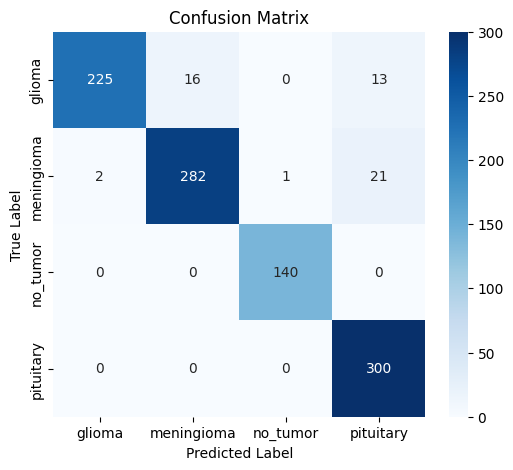

In [36]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()